In [3]:
!pip install contextily

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd


In [22]:
# Load the shapefiles
philippines = gpd.read_file("/Users/jackywong1105/Desktop/Project 1/Monsoon Rainfall/PHL_adm2.shp")
metro_manila = gpd.read_file("/Users/jackywong1105/Desktop/Project 1/Monsoon Rainfall/Metro_Manila_Box.shp")


In [41]:
# Load the station data from CSV
stations_df = pd.read_csv("/Users/jackywong1105/Desktop/Project 1/Monsoon Rainfall/4078832.csv")


/var/folders/6s/rz60r97n7lsgxbhkfswp4qc00000gn/T/ipykernel_3874/3621458629.py:2: DtypeWarning: Columns (7,9,11,15,17,25,27,29,31,33,35,37,39,41,43,45,47) have mixed types. Specify dtype option on import or set low_memory=False.
  stations_df = pd.read_csv("/Users/jackywong1105/Desktop/Project 1/Monsoon Rainfall/4078832.csv")


In [42]:
stations_df

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,ACMH,ACMH_ATTRIBUTES,ACSH,ACSH_ATTRIBUTES,...,WT06,WT06_ATTRIBUTES,WT07,WT07_ATTRIBUTES,WT08,WT08_ATTRIBUTES,WT16,WT16_ATTRIBUTES,WT18,WT18_ATTRIBUTES
0,RPW00041228,"MANILA NF, RP",14.600,121.0,33.2,1946-07-01,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,",,X",NaN,NaN
1,RPW00041228,"MANILA NF, RP",14.600,121.0,33.2,1946-07-02,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,",,X",NaN,NaN
2,RPW00041228,"MANILA NF, RP",14.600,121.0,33.2,1946-07-03,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,",,X",NaN,NaN
3,RPW00041228,"MANILA NF, RP",14.600,121.0,33.2,1946-07-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,",,X",NaN,NaN
4,RPW00041228,"MANILA NF, RP",14.600,121.0,33.2,1946-07-05,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72020,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,15.0,2025-07-15,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72021,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,15.0,2025-07-16,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72022,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,15.0,2025-07-17,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72023,RP000098429,"NINOY AQUINO INTERN, RP",14.517,121.0,15.0,2025-07-18,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# Extract unique stations based on STATION or NAME
unique_stations = stations_df[['STATION', 'NAME', 'LATITUDE', 'LONGITUDE']].drop_duplicates(subset=['STATION'])


In [44]:
unique_stations

,STATION,NAME,LATITUDE,LONGITUDE
0,RPW00041228,"MANILA NF, RP",14.60000,121.00000
215,RPW00041229,"MANILA, RP",14.55000,120.98333
14534,RPW00041227,"MANILA NF, RP",14.60000,121.00000
14672,RPW00041224,"SANGLEY POINT, RP",14.49472,120.91138
23700,RP000098430,"SCIENCE GARDEN, RP",14.63300,121.01700
46777,RP000098429,"NINOY AQUINO INTERN, RP",14.51700,121.00000


In [45]:
# Verify we have exactly 6 stations
print("Number of unique stations:", len(unique_stations))
print(unique_stations[['STATION', 'NAME', 'LATITUDE', 'LONGITUDE']])


Number of unique stations: 6
           STATION                     NAME  LATITUDE  LONGITUDE
0      RPW00041228            MANILA NF, RP  14.60000  121.00000
215    RPW00041229               MANILA, RP  14.55000  120.98333
14534  RPW00041227            MANILA NF, RP  14.60000  121.00000
14672  RPW00041224        SANGLEY POINT, RP  14.49472  120.91138
23700  RP000098430       SCIENCE GARDEN, RP  14.63300  121.01700
46777  RP000098429  NINOY AQUINO INTERN, RP  14.51700  121.00000


In [46]:
# Convert the station data to a GeoDataFrame
stations_gdf = gpd.GeoDataFrame(
    unique_stations,
    geometry=gpd.points_from_xy(unique_stations["LONGITUDE"], unique_stations["LATITUDE"]),
    crs="EPSG:4326"
)


In [47]:
philippines = philippines.to_crs(epsg=4326)
metro_manila = metro_manila.to_crs(epsg=4326)
stations_gdf = stations_gdf.to_crs(epsg=4326)



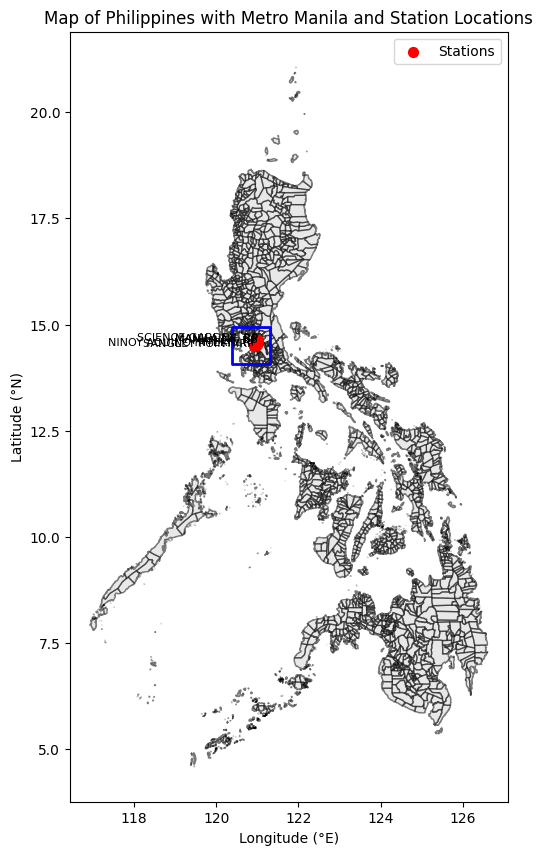

In [50]:
# Create a figure and axis for the map
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the Philippines basemap
philippines.plot(ax=ax, color="lightgray", edgecolor="black", alpha=0.5)

# Plot the Metro Manila polygon
metro_manila.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=2)

# Plot the station locations
stations_gdf.plot(ax=ax, color="red", markersize=50, label="Stations")

# Add station labels
for x, y, name in zip(stations_gdf.geometry.x, stations_gdf.geometry.y, stations_gdf["NAME"]):
    ax.text(x, y, name, fontsize=8, ha="right")

# Set axis labels
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")

# Add title and legend
plt.title("Map of Philippines with Metro Manila and Station Locations")
ax.legend()

# Show the plot
plt.show()


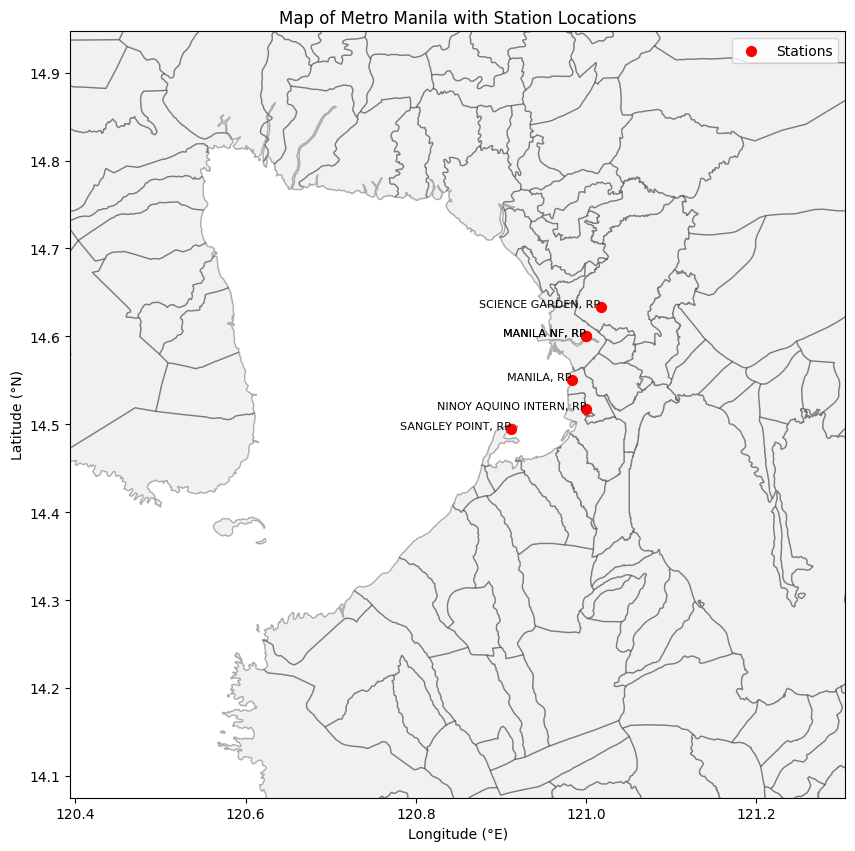

In [53]:
# Create a figure and axis for the map
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the Philippines basemap for context
philippines.plot(ax=ax, color="lightgray", edgecolor="black", alpha=0.3)

# Plot the Metro Manila polygon
metro_manila.plot(ax=ax, facecolor="none", edgecolor="none", linewidth=2)

# Plot the station locations
stations_gdf.plot(ax=ax, color="red", markersize=50, label="Stations")

# Add station labels
for x, y, name in zip(stations_gdf.geometry.x, stations_gdf.geometry.y, stations_gdf["NAME"]):
    ax.text(x, y, name, fontsize=8, ha="right")

# Set axis limits to focus on Metro Manila
minx, miny, maxx, maxy = metro_manila.total_bounds
ax.set_xlim(minx , maxx )  # Add padding for visibility
ax.set_ylim(miny , maxy )

# Set axis labels
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")

# Add title and legend
plt.title("Map of Metro Manila with Station Locations")
ax.legend()

# Save the map as an image
plt.savefig("metro_manila_map.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()